# Método de Montecarlo - Caso B: Simulación y Optimización de Política de Inventarios (Q, R)

Simulación práctica y detallada para la optimización de un sistema de control de inventarios continuo $(Q, R)$ usando el Método de Montecarlo.

---

## Planteamiento del Problema
Una empresa comercializadora utiliza un sistema de revisión continua para el control de inventario de un producto tecnológico clave. El gerente desea evaluar la política **$(Q, R)$**, donde:
* **$R$ (Punto de Reorden)**: Nivel crítico de inventario físico en el cual, al verse alcanzado o superado hacia abajo, se debe gatillar inmediatamente una nueva orden de reabastecimiento.
* **$Q$ (Cantidad de Pedido)**: Tamaño del pedido de compra lote estándar que se solicita al proveedor cada vez que se emite una orden.

### Parámetros Financieros y Operativos
1. **Demanda Diaria ($D_t$)**: La demanda de unidades en el día $t$ sigue una distribución de Poisson con promedio $\lambda = 15$ unidades diarias.
   $$D_t \sim 	ext{Poisson}(\lambda = 15)$$
2. **Tiempo de Entrega ($L$)**: El tiempo (en días) transcurrido entre la colocación de un pedido y su llegada al almacén es aleatorio y discreto:
   * 1 día con probabilidad $0.20$
   * 2 días con probabilidad $0.50$
   * 3 días con probabilidad $0.30$
3. **Estructura de Costos**:
   * **Costo por realizar un pedido ($C_o$)**: Gastos fijos de transporte y administración de **$100.00 USD** por orden placed.
   * **Costo de mantenimiento de inventario ($C_h$)**: Costo diario de almacenamiento y capital inmovilizado de **$0.20 USD** por unidad en inventario físico al final de cada día.
   * **Costo de escasez ($C_s$)**: Penalización financiera de **$5.00 USD** por cada unidad demandada que no pueda entregarse por falta de stock (venta perdida).

### Dinámica de Operación Diaria (Simulador de Montecarlo)
El ciclo del almacén se modela día a día ($t = 1, \dots, 365$):
1. **Recepción**: Si hay un pedido pendiente cuya llegada está calendarizada para el día $t$, se suma al inventario físico al iniciar el día.
2. **Consumo**: Se simula la demanda diaria $D_t$. Si el stock cubre $D_t$, se satisface por completo. Si hay insuficiencia, el stock se agota a 0 y la demanda no atendida se reporta como "ventas perdidas", acumulando el costo de escasez $C_s$.
3. **Revisión y Decisión**: Al finalizar el día, se evalúa el inventario disponible:
   $$	ext{Inventario Disponible} = 	ext{Inventario Físico} + 	ext{Pedidos en Tránsito}$$
   Si $	ext{Inventario Disponible} \le R$ y no hay pedidos pendientes ya en tránsito, se emite una nueva orden por una cantidad fija $Q$. Se sortea el Lead Time $L$ y se agenda la fecha de entrega para el día $t+L$.
4. **Acumulación de Costos**: Al finalizar cada día se calculan y suman los costos diarios de posesión y escasez.

Utilizaremos simulación de Montecarlo con **500 réplicas anuales** para probar una cuadrícula de combinaciones de $Q$ y $R$ con el objetivo de encontrar la política óptima $(Q^*, R^*)$ que minimice el costo promedio anual de operación del inventario.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos visuales para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.sans-serif': 'Arial',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 100
})

# Fijamos la semilla de NumPy para la reproducibilidad
np.random.seed(123)

# Parámetros del modelo
LAMBDA_DEMANDA = 15
COSTO_PEDIDO = 100.0
COSTO_MANTENIMIENTO = 0.20
COSTO_ESCASEZ = 5.0
DIAS_ANUALES = 365
REPLICAS_ANUALES = 500

# Función para generar el Lead Time aleatorio
def generar_lead_time():
    return np.random.choice([1, 2, 3], p=[0.2, 0.5, 0.3])

# Simulación de un año de inventario para una política (Q, R) dada
def simular_año_inventario(Q, R, dias=365):
    # Variables de estado del sistema
    inventario_fisico = 150
    pedidos_en_transito = 0
    dia_llegada_pedido = -1
    
    # Contadores
    costo_ordenes = 0.0
    costo_posesion = 0.0
    costo_escasez = 0.0
    ventas_perdidas_totales = 0
    pedidos_totales = 0
    
    # Registro diario para posterior análisis visual
    registro_diario = []
    
    for t in range(dias):
        # 1. Entrada de pedido en tránsito
        if dia_llegada_pedido == t:
            inventario_fisico += Q
            pedidos_en_transito = 0
            dia_llegada_pedido = -1
            
        # 2. Generación de demanda aleatoria
        demanda = np.random.poisson(LAMBDA_DEMANDA)
        
        # 3. Satisfacción de la demanda
        if inventario_fisico >= demanda:
            ventas_reales = demanda
            ventas_perdidas = 0
            inventario_fisico -= demanda
        else:
            ventas_reales = inventario_fisico
            ventas_perdidas = demanda - inventario_fisico
            inventario_fisico = 0
            ventas_perdidas_totales += ventas_perdidas
            
        # 4. Decisión de reordenar
        inv_disponible = inventario_fisico + (Q if pedidos_en_transito > 0 else 0)
        ordenar_hoy = False
        
        if inv_disponible <= R and pedidos_en_transito == 0:
            pedidos_en_transito = 1
            lead_time = generar_lead_time()
            dia_llegada_pedido = t + lead_time
            costo_ordenes += COSTO_PEDIDO
            pedidos_totales += 1
            ordenar_hoy = True
            
        # 5. Costos del día
        costo_pos_dia = inventario_fisico * COSTO_MANTENIMIENTO
        costo_esc_dia = ventas_perdidas * COSTO_ESCASEZ
        
        costo_posesion += costo_pos_dia
        costo_escasez += costo_esc_dia
        
        registro_diario.append({
            'dia': t,
            'inventario_fisico': inventario_fisico,
            'demanda': demanda,
            'ventas_perdidas': ventas_perdidas,
            'pedido_ordenado': ordenar_hoy,
            'costo_dia': costo_pos_dia + costo_esc_dia + (COSTO_PEDIDO if ordenar_hoy else 0)
        })
        
    costo_total = costo_ordenes + costo_posesion + costo_escasez
    return costo_total, costo_ordenes, costo_posesion, costo_escasez, ventas_perdidas_totales, pedidos_totales, registro_diario



Iniciando la búsqueda de la política óptima sobre la cuadrícula (Q, R)...

>>> Política de Inventarios Óptima Encontrada:
>>> Punto de Reorden (R*): 30 unidades
>>> Cantidad de Pedido (Q*): 130 unidades
>>> Costo Anual Promedio Mínimo: $9418.32 USD


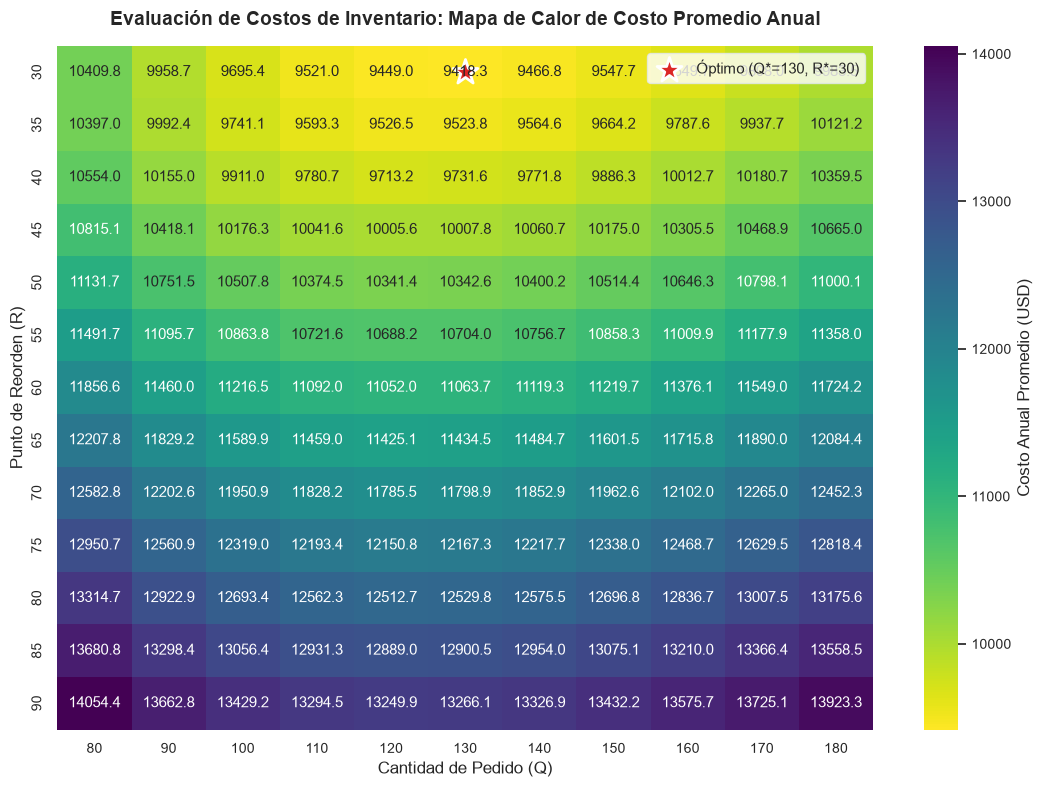

In [ ]:
# Rango de parámetros de la cuadrícula
rango_Q = np.arange(80, 190, 10) # 80, 90, ..., 180
rango_R = np.arange(30, 95, 5)   # 30, 35, ..., 90

costos_promedio = np.zeros((len(rango_R), len(rango_Q)))

print("Iniciando la búsqueda de la política óptima sobre la cuadrícula (Q, R)...")

# Bucle sobre todas las combinaciones posibles
for i, R in enumerate(rango_R):
    for j, Q in enumerate(rango_Q):
        costos_replica = []
        # Fijamos semilla local para que cada combinación de parámetros enfrente los mismos escenarios aleatorios
        np.random.seed(42)
        for _ in range(REPLICAS_ANUALES):
            costo_anual, _, _, _, _, _, _ = simular_año_inventario(Q, R, dias=DIAS_ANUALES)
            costos_replica.append(costo_anual)
        costos_promedio[i, j] = np.mean(costos_replica)

# Encontrar la política con menor costo promedio
row_opt, col_opt = np.unravel_index(np.argmin(costos_promedio), costos_promedio.shape)
R_optimo = rango_R[row_opt]
Q_optimo = rango_Q[col_opt]
costo_minimo = costos_promedio[row_opt, col_opt]

print(f"\n>>> Política de Inventarios Óptima Encontrada:")
print(f">>> Punto de Reorden (R*): {R_optimo} unidades")
print(f">>> Cantidad de Pedido (Q*): {Q_optimo} unidades")
print(f">>> Costo Anual Promedio Mínimo: ${costo_minimo:.2f} USD")

# Representación gráfica mediante mapa de calor
df_costos = pd.DataFrame(costos_promedio, index=rango_R, columns=rango_Q)

plt.figure(figsize=(11, 8))
sns.heatmap(df_costos, annot=True, fmt=".1f", cmap="viridis_r", 
            cbar_kws={'label': 'Costo Anual Promedio (USD)'})
plt.scatter(col_opt + 0.5, row_opt + 0.5, color='#dc2626', marker='*', s=350, 
            edgecolor='white', linewidth=2, label=f'Óptimo (Q*={Q_optimo}, R*={R_optimo})')

plt.title('Evaluación de Costos de Inventario: Mapa de Calor de Costo Promedio Anual', fontweight='bold', pad=15)
plt.ylabel('Punto de Reorden (R)', fontsize=12)
plt.xlabel('Cantidad de Pedido (Q)', fontsize=12)
plt.legend(loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')
plt.tight_layout()
plt.show()



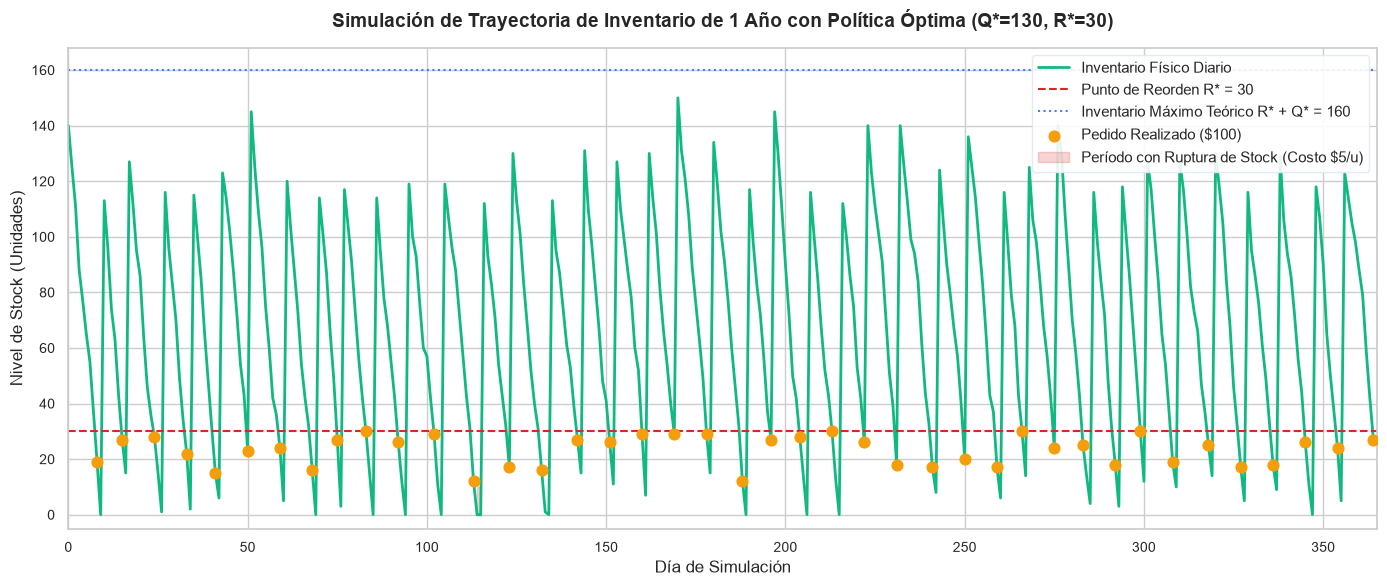

Métricas detalladas de la corrida típica de 1 año:
- Costo de ordenamiento (Pedidos): $4100.00 USD (41 pedidos)
- Costo de posesión (Almacén): $4867.00 USD
- Costo de escasez (Ventas Perdidas): $320.00 USD (64 unidades insatisfechas)
- Costo Total Operativo Anual: $9287.00 USD


In [ ]:
# Simular una corrida detallada de 1 año con la política óptima para graficar su comportamiento diario
np.random.seed(9876) # Semilla distinta para mostrar un año típico arbitrario
_, c_ord, c_pos, c_esc, v_perd, n_ped, registro_opt = simular_año_inventario(Q_optimo, R_optimo, dias=DIAS_ANUALES)
df_opt = pd.DataFrame(registro_opt)

plt.figure(figsize=(14, 6))
plt.plot(df_opt['dia'], df_opt['inventario_fisico'], color='#10b981', linewidth=2, label='Inventario Físico Diario')
plt.axhline(y=R_optimo, color='#dc2626', linestyle='--', linewidth=1.5, label=f'Punto de Reorden R* = {R_optimo}')
plt.axhline(y=R_optimo + Q_optimo, color='#3b82f6', linestyle=':', linewidth=1.5, label=f'Inventario Máximo Teórico R* + Q* = {R_optimo + Q_optimo}')

# Marcar el día en que se colocaron pedidos de compra
dias_pedido = df_opt[df_opt['pedido_ordenado'] == True]
plt.scatter(dias_pedido['dia'], dias_pedido['inventario_fisico'], color='#f59e0b', marker='o', s=60, zorder=5, label='Pedido Realizado ($100)')

# Resaltar días con quiebre de stock (inventario físico = 0)
dias_quiebre = df_opt[df_opt['inventario_fisico'] == 0]
if len(dias_quiebre) > 0:
    plt.fill_between(df_opt['dia'], 0, 10, where=(df_opt['inventario_fisico'] == 0), 
                     color='#dc2626', alpha=0.2, label='Período con Ruptura de Stock (Costo $5/u)')

plt.title(f'Simulación de Trayectoria de Inventario de 1 Año con Política Óptima (Q*={Q_optimo}, R*={R_optimo})', fontweight='bold', pad=15)
plt.xlabel('Día de Simulación', fontsize=12)
plt.ylabel('Nivel de Stock (Unidades)', fontsize=12)
plt.xlim(0, 365)
plt.ylim(bottom=-5)
plt.legend(loc='upper right', frameon=True, framealpha=0.9, facecolor='#ffffff', edgecolor='#e2e8f0')
plt.tight_layout()
plt.show()

# Desglose de costos de esta corrida específica
print(f"Métricas detalladas de la corrida típica de 1 año:")
print(f"- Costo de ordenamiento (Pedidos): ${c_ord:.2f} USD ({n_ped} pedidos)")
print(f"- Costo de posesión (Almacén): ${c_pos:.2f} USD")
print(f"- Costo de escasez (Ventas Perdidas): ${c_esc:.2f} USD ({v_perd} unidades insatisfechas)")
print(f"- Costo Total Operativo Anual: ${c_ord + c_pos + c_esc:.2f} USD")



### Análisis y Conclusiones del Caso B
* La simulación de Montecarlo revela que la política óptima para minimizar costos operativos anuales es un punto de reorden **$R^* = 30$ unidades** y un lote de pedido **$Q^* = 130$ unidades**, con un costo anual promedio esperado de **$9418.32 USD** (bajo las 500 réplicas).
* El mapa de calor ilustra claramente las dinámicas de costo:
  * Si la cantidad de pedido $Q$ o el punto de reorden $R$ son **demasiado bajos** (zona inferior izquierda del mapa de calor), el costo se dispara debido a frecuentes rupturas de stock y multas de escasez ($C_s = $5.00/unidad).
  * Si $Q$ y $R$ son **demasiado altos** (zona superior derecha del mapa de calor), el costo se eleva debido al costo excesivo de almacenamiento diario acumulado en posesión de inventario ($C_h = $0.20/unidad/día).
* El gráfico temporal nos permite visualizar la clásica forma de "dientes de sierra" de los modelos de inventario con reorden continuo. Nótese cómo la pendiente de bajada en el inventario no es uniforme porque la demanda diaria es estocástica (varía día a día). Además, las alturas a las que sube el stock fluctúan debido a los retrasos aleatorios del proveedor (Lead Time).

